# Finding/opening ACCESS-OM3 `MC_25km_jra_ryf-1.0-beta` test run output using intake

This notebook demonstrates how to using intake-esm to find and load data data from the ACCESS-OM3 `MC_25km_jra_ryf-1.0-beta` test run.

For more information about using intake-esm to find and load data, see:
- the [intake-esm documentation](https://intake-esm.readthedocs.io/en/stable/)
- [this section](https://access-nri-intake-catalog.readthedocs.io/en/latest/usage/quickstart.html#using-an-intake-esm-datastore) of the access-nri-intake-catalog documentation

In [8]:
#This cell must be in all notebooks!
#It allows us to run all the notebooks at once, this cell has a tag "parameters" which allows us to pass in 
# arguments externally using papermill (see mkfigs.sh for details)

### USER EDIT start
esm_file = "/scratch/ps29/nd0349/access-om3/archive/IC4M8-MCW-100km_jra_iaf_2010/experiment_datastore.json"
dpi=300
### USER EDIT stop

import os
from matplotlib import rcParams
%matplotlib inline
rcParams["figure.dpi"]= dpi

plotfolder=f"/g/data/{os.environ['PROJECT']}/{os.environ['USER']}/access-om3-analysis-figs/"
os.makedirs(plotfolder, exist_ok=True)

 # a similar cell under this means it's being run in batch
print("ESM datastore path: ",esm_file)
print("Plot folder path: ",plotfolder)

ESM datastore path:  /scratch/ps29/nd0349/access-om3/archive/IC4M8-MCW-100km_jra_iaf_2010/experiment_datastore.json
Plot folder path:  /g/data/ps29/nd0349/access-om3-analysis-figs/


In [9]:
from intake import cat
from xarray import DataTree, map_over_datasets
from distributed import Client
import glob
import xarray as xr
import cf_xarray
import numpy as np
from datetime import timedelta
import cf_xarray as cfxr
import xesmf
import re
import os
import time
import intake


# Plotting
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean.cm as cmo
import matplotlib.lines as mlines
import cartopy.feature as cft

# Import my functions
functions_path = os.path.abspath("/home/566/nd0349/access-om3-analysis/functions")
if functions_path not in sys.path:
    sys.path.append(functions_path)
from get_files import *
from plot_settings import *
from fstd import *
from parameters import *
π = np.pi
test()

Functions from get_files.py imported!


In [10]:
client = Client(threads_per_worker=1)
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 42303 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/42303/status,
Dashboard: /proxy/42303/status,Workers: 7
Total threads: 7,Total memory: 32.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:37465,Workers: 0
Dashboard: /proxy/42303/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:35607,Total threads: 1
Dashboard: /proxy/36015/status,Memory: 4.57 GiB
Nanny: tcp://127.0.0.1:35853,


In [11]:
print(client.dashboard_link)

/proxy/42303/status


### Open the intake-esm datastore

In [14]:
COLUMNS_WITH_ITERABLES = [
        "variable",
        "variable_long_name",
        "variable_standard_name",
        "variable_cell_methods",
        "variable_units"
]

datastore = intake.open_esm_datastore(
    esm_file,
    columns_with_iterables=COLUMNS_WITH_ITERABLES
)


### What ocean variables are available at monthly frequency?

In [15]:
def available_variables(datastore):
    """Return a pandas dataframe summarising the variables in a datastore"""
    variable_columns = [col for col in datastore.df.columns if "variable" in col]
    return (
        datastore.df[variable_columns]
        .explode(variable_columns)
        .drop_duplicates()
        .set_index("variable")
        .sort_index()
    )

In [16]:
datastore_filtered = datastore.search(realm="wave", frequency="fx")

available_variables(datastore_filtered)

,variable_long_name,variable_standard_name,variable_cell_methods,variable_units
variable,,,,
EF,1D spectral density,,,m2 s
FP0,Peak frequency,,,s-1
HS,Significant wave height,,,m
ICE,Ice coverage,,,nd
ICEF,Ice floe diameter,,,m
ICEH,Ice thickness,,,m
T01,"Mean wave period (Tm0,1)",,,s
T02,"Mean wave period (Tm0,2)",,,s
T0M1,"Mean wave period (Tm0,-1)",,,s


### Load monthly sea surface height (`zos`) and plot the field at the last available time

In [17]:
hs = datastore.search(variable="HS").to_dask(
    xarray_combine_by_coords_kwargs = dict( # These kwargs can make things faster
        compat="override",
        data_vars="minimal",
        coords="minimal",
    ),
    xarray_open_kwargs = dict(
        chunks={"yh": -1, "xh": -1}, # Good for spatial operations, but not temporal
        decode_timedelta=True
    )
)


In [18]:
hs = hs.roll(lonh=80, roll_coords=True).isel(time=slice(-365,))

ValueError: Dimensions ['lonh'] not found in data dimensions ('time', 'ny', 'nx')

In [ ]:
coords = datastore.search(variable=["geolat", "geolon"], file_id='access_om3_mom6_geometry').to_dask().compute()
coords = coords.fillna(0.0)

# zos = zos.assign_coords(coords)
coords

In [ ]:
# datastore.search(variable=["geolat", "geolon"]).unique()

In [ ]:
proj = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(15,6), subplot_kw=dict(projection=proj))

pcm = ax.pcolormesh(
    coords['geolon'],
    coords['geolat'],
    hs["HS"].isel(time=-1),
    transform=ccrs.PlateCarree()
)

ax.coastlines()
ax.gridlines(draw_labels=True)

plt.colorbar(pcm, ax=ax, orientation='vertical', label='Hs (m)')
plt.show()

## Read in WHACS

In [ ]:
# Load WHACS t02 and compute all-time mean (cached)
if os.path.exists(whacs_cache_file):
    print(f"Loading cached WHACS mean: {whacs_cache_file}")
    whacs_mean = xr.open_dataset(whacs_cache_file)["t02"]
else:
    whacs_files = sorted(glob.glob(whacs_file_glob))
    if len(whacs_files) == 0:
        raise FileNotFoundError(f"No WHACS files matched glob: {whacs_file_glob}")

    print("WHACS nfiles:", len(whacs_files))
    print("WHACS first:", whacs_files[0])
    print("WHACS last :", whacs_files[-1])

    ds_whacs = xr.open_mfdataset(
        whacs_files,
        combine="by_coords",
        parallel=True,
        chunks={"time": 744},
    )
    da_whacs = ds_whacs["t02"].astype("float32")
    whacs_mean = da_whacs.mean("time").compute()

    whacs_mean.to_dataset(name="t02").to_netcdf(
        whacs_cache_file,
        encoding={
            "t02": {
                "zlib": True,
                "complevel": 4,
                "dtype": "float32",
                "_FillValue": -1.0e20,
            }
        },
    )
    print(f"Saved WHACS mean to {whacs_cache_file}")

print("WHACS mean dims:", whacs_mean.dims)

In [12]:
import xarray as xr
import numpy as np
import pandas as pd
from tqdm import tqdm

import cartopy
import cartopy.io.img_tiles as cimgt
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter

import matplotlib.pyplot as plt
import matplotlib.path as mpath
from matplotlib.dates import MonthLocator
import matplotlib.colors as mc
from matplotlib.pyplot import *

from shapely.geometry import Point, Polygon
from shapely.prepared import prep
from shapely import buffer, difference, covers, prepare

from siphon.catalog import TDSCatalog
from scipy.spatial import KDTree
from wavespectra.construct import construct_partition

from typing import Tuple
import numpy.typing as npt
from pyproj import Proj, Transformer
from scipy.spatial import KDTree

In [36]:
base = '/g/data/ia39/WP3/release/ACS_hindcast/gridded/release/WP3/WHACS/BoM-CSIRO/hindcast/ERA5/ERA5/WHACS/WWIII-v6.07/global-R8/1hr/hs'
files = glob.glob(base + '/*.nc')
print(len(files))
base = '/g/data/ia39/WP3/release/ACS_hindcast/gridded/release/WP3/WHACS/BoM-CSIRO/hindcast/ERA5/ERA5/WHACS/WWIII-v6.07/global-R8/1hr/hs'
files = sorted(glob.glob(base + '/*.nc'))
print(len(files))
print(files[372:]) # Jan 2010

hs_whacs = xr.open_mfdataset(
    files[-1],
    combine='by_coords',
    parallel=True,
    # chunks={'time': 240}  # adjust depending on memory
)

540
540
['/g/data/ia39/WP3/release/ACS_hindcast/gridded/release/WP3/WHACS/BoM-CSIRO/hindcast/ERA5/ERA5/WHACS/WWIII-v6.07/global-R8/1hr/hs/hs_WHACS_hindcast_WHACS_ERA5_1hr_201001010000-201001312300.nc', '/g/data/ia39/WP3/release/ACS_hindcast/gridded/release/WP3/WHACS/BoM-CSIRO/hindcast/ERA5/ERA5/WHACS/WWIII-v6.07/global-R8/1hr/hs/hs_WHACS_hindcast_WHACS_ERA5_1hr_201002010000-201002282300.nc', '/g/data/ia39/WP3/release/ACS_hindcast/gridded/release/WP3/WHACS/BoM-CSIRO/hindcast/ERA5/ERA5/WHACS/WWIII-v6.07/global-R8/1hr/hs/hs_WHACS_hindcast_WHACS_ERA5_1hr_201003010000-201003312300.nc', '/g/data/ia39/WP3/release/ACS_hindcast/gridded/release/WP3/WHACS/BoM-CSIRO/hindcast/ERA5/ERA5/WHACS/WWIII-v6.07/global-R8/1hr/hs/hs_WHACS_hindcast_WHACS_ERA5_1hr_201004010000-201004302300.nc', '/g/data/ia39/WP3/release/ACS_hindcast/gridded/release/WP3/WHACS/BoM-CSIRO/hindcast/ERA5/ERA5/WHACS/WWIII-v6.07/global-R8/1hr/hs/hs_WHACS_hindcast_WHACS_ERA5_1hr_201005010000-201005312300.nc', '/g/data/ia39/WP3/release/

In [37]:
hs

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 5113, ny: 300, nx: 360)
Coordinates:
  * time     (time) datetime64[ns] 41kB 2010-01-02 2010-01-03 ... 2037-11-30
Dimensions without coordinates: ny, nx
Data variables:
    HS       (time, ny, nx) float32 2GB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
Attributes:
    intake_esm_vars:                          ['HS']
    intake_esm_attrs:file_id:                 access_om3_ww3_hi_XXXX_XX_XX_XXXXX
    intake_esm_attrs:frequency:               fx
    intake_esm_attrs:variable:                mapsta,UAX,UAY,ICE,ICEH,ICEF,HS...
    intake_esm_attrs:variable_long_name:      map status,Mean wind, x-compone...
    intake_esm_attrs:variable_standard_name:  ,,,,,,,,,,,,,,
    intake_esm_attrs:variable_cell_methods:   ,,,,,,,,,,,,,,
    intake_esm_attrs:variable_units:          unitless,m s-1,m s-1,nd,m,m,m,s...
    intake_esm_attrs:realm:                   wave
    intake_esm_attrs:_data_format_:           netcdf
    intake_esm_dataset_key:                   access_om3_ww3_hi_XXXX_XX_XX_XX...

In [38]:
hs_whacs

<xarray.Dataset> Size: 21GB
Dimensions:                      (longitude: 2881, latitude: 1201, time: 744)
Coordinates:
  * longitude                    (longitude) float32 12kB 0.0 0.125 ... 360.0
  * latitude                     (latitude) float32 5kB -75.0 -74.88 ... 75.0
  * time                         (time) datetime64[ns] 6kB 2023-12-01 ... 202...
Data variables:
    hs                           (time, latitude, longitude) float64 21GB dask.array<chunksize=(372, 51, 121), meta=np.ndarray>
    projected_coordinate_system  int32 4B ...
Attributes: (12/58)
    Conventions:                     CF-1.11 ACDD-1.3
    title:                           Wave Hindcast for the Australian Climate...
    summary:                         Wave Hindcast for the Australian Climate...
    keywords:                        WHACS, ACS, waves, ocean, coast, WWIII, ...
    id:                              BoM-CSIRO-WHACS-001
    naming_authority:                au.csiro
    ...                              ...
    geospatial_lon_max:              360.0
    geospatial_vertical_positive:    up
    time_coverage_start:             2023-12-01T00:00:00
    time_coverage_end:               2023-12-31T23:00:00
    time_coverage_duration:          P30DT23H0M0S
    time_coverage_resolution:        P0DT1H0M0S

In [47]:
coords_rolled = coords.roll(lonh=80, roll_coords=True)
coords_rolled['geolon']

<xarray.DataArray 'geolon' (lath: 300, lonh: 360)> Size: 864kB
array([[ 0.5       ,  1.5       ,  2.5       , ..., -2.5       ,
        -1.5       , -0.5       ],
       [ 0.5       ,  1.5       ,  2.5       , ..., -2.5       ,
        -1.5       , -0.5       ],
       [ 0.5       ,  1.5       ,  2.5       , ..., -2.5       ,
        -1.5       , -0.5       ],
       ...,
       [54.46056889, 56.47744886, 58.22512043, ..., 46.07242431,
        49.35067864, 52.11191214],
       [63.98952828, 65.35084698, 66.510362  , ..., 58.0034739 ,
        60.41202175, 62.36965146],
       [74.52840857, 75.01296597, 75.42150662, ..., 72.31997671,
        73.225545  , 73.94414274]])
Coordinates:
  * lath     (lath) float64 2kB -77.88 -77.63 -77.38 ... 88.87 89.32 89.77
  * lonh     (lonh) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... -4.5 -3.5 -2.5 -1.5 -0.5
Attributes:
    long_name:  longitude at tracer (T) points
    units:      degree

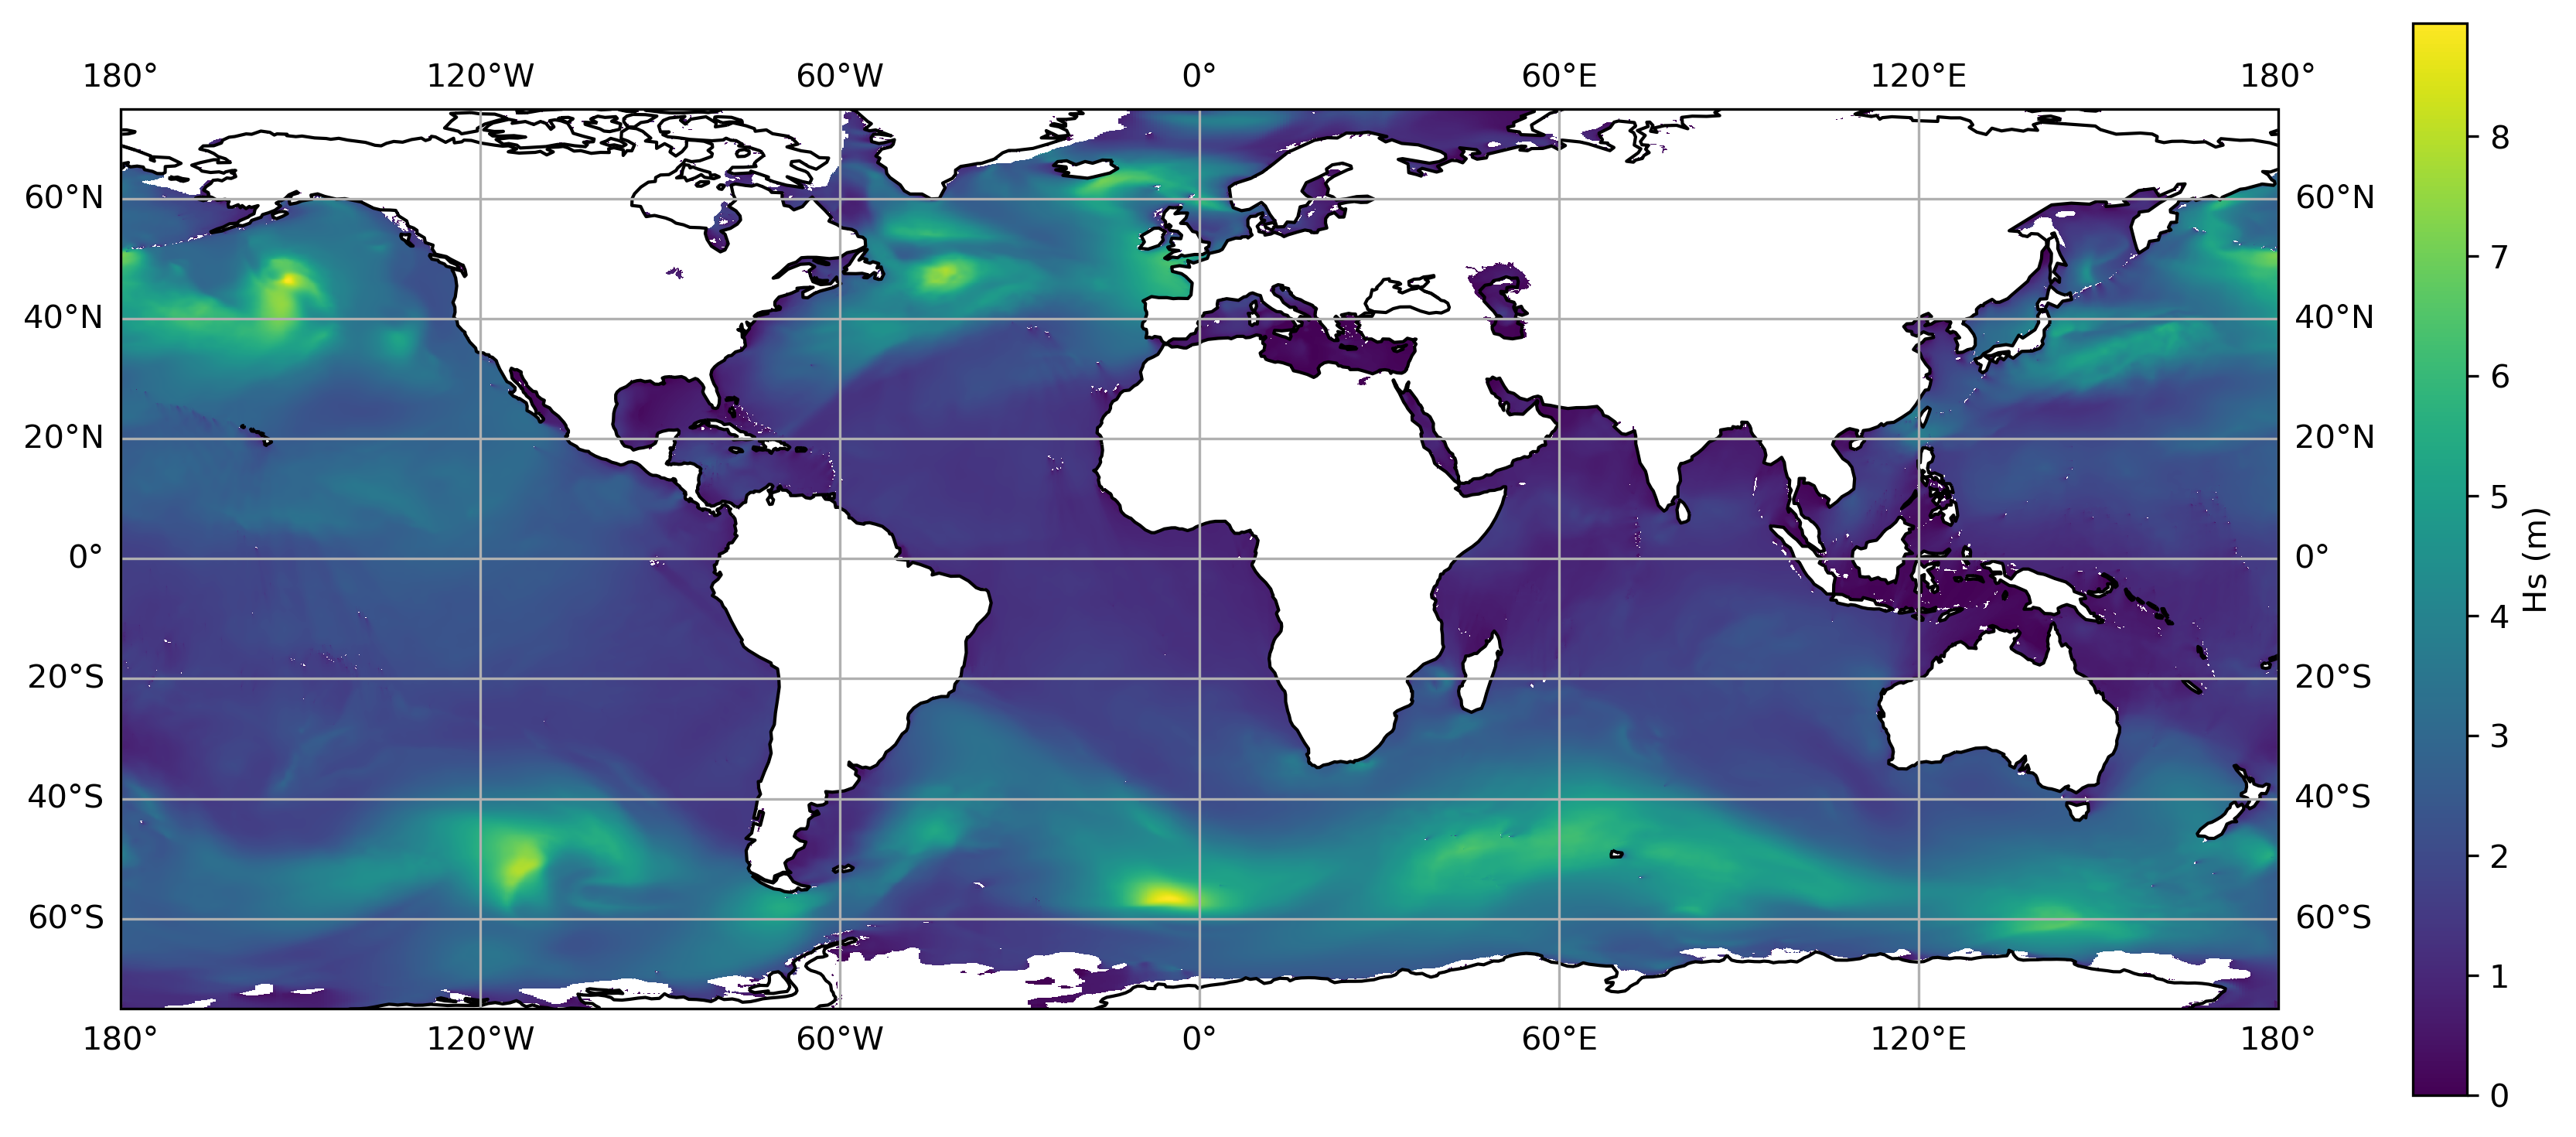

In [41]:
proj = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(15,6), subplot_kw=dict(projection=proj))

pcm = ax.pcolormesh(
    hs_whacs['longitude'],
    hs_whacs['latitude'],
    hs_whacs.isel(time=-1)["hs"],
    transform=ccrs.PlateCarree()
)

ax.coastlines()
ax.gridlines(draw_labels=True)

plt.colorbar(pcm, ax=ax, orientation='vertical', label='Hs (m)')
plt.show()

In [ ]:
ds_src = hs_whacs.rename({
    "longitude": "lon",
    "latitude": "lat"
})

# Ensure 2D grid if needed
if ds_src.lon.ndim == 1 and ds_src.lat.ndim == 1:
    ds_src = ds_src.assign_coords(
        lon=("lon", ds_src.lon.values),
        lat=("lat", ds_src.lat.values)
    )

In [51]:
ds_out = xr.Dataset(
    {
        "lat": (("ny", "nx"), coords_rolled["geolat"].values),
        "lon": (("ny", "nx"), coords_rolled["geolon"].values),
    }
)

In [52]:
ds_src["lon"] = ((ds_src["lon"] + 180) % 360) - 180
regridder = xesmf.Regridder(
    ds_src,
    ds_out,
    method="bilinear",      # or "conservative" if you need area conservation
    periodic=True           # important for global grids
)
hs_regridded = regridder(
    ds_src.isel(time=-1)["hs"]
)

ValueError: ESMC_FieldRegridStore failed with rc = 506. Please check the log files (named "*ESMF_LogFile").

In [ ]:
proj = ccrs.PlateCarree()

fig, ax = plt.subplots(figsize=(15,6), subplot_kw=dict(projection=proj))

pcm = ax.pcolormesh(
    coords["geolon"],
    coords["geolat"],
    hs_regridded,
    transform=ccrs.PlateCarree()
)

ax.coastlines()
ax.gridlines(draw_labels=True)

plt.colorbar(pcm, ax=ax, label="Hs (m)")
plt.show()

In [ ]:
client.close()